In [1]:
import numpy as np
import pandas as pd
from fractions import Fraction
from math import floor, gcd, log
 
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.transpiler import CouplingMap, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
 
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler


def M2mod15():
    b = 2 # multiplier
    U = QuantumCircuit(4) # create a 4-qubit quantum circuit
    # swap qubits, shifting the binary number left by 1 (multiply by 2)
    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)
    # Turn circuit into a gate for easy reuse
    U = U.to_gate()
    U.name = f"M_{b}"
 
    return U

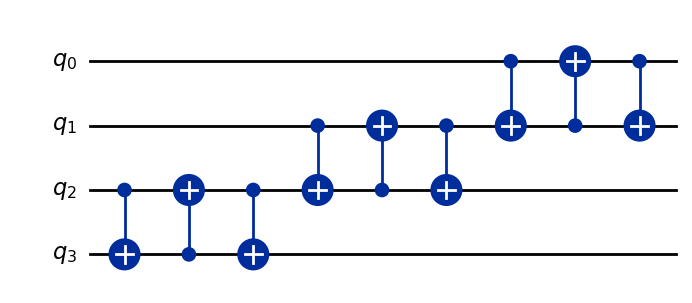

In [2]:
# Get the M2 operator
M2 = M2mod15()
 
# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M2, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

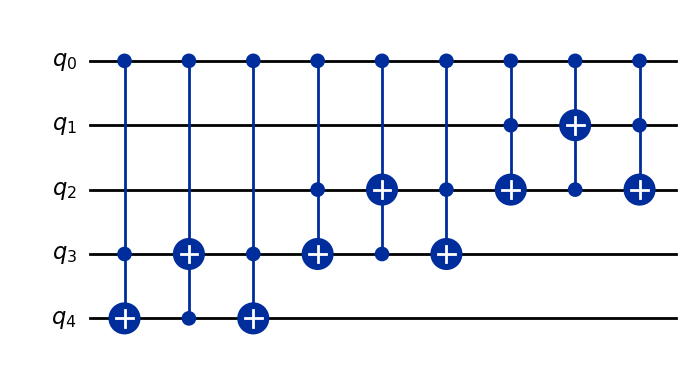

In [3]:
def controlled_M2mod15():
    """
    Controlled M2 (mod 15)
    """
    b = 2
    U = QuantumCircuit(4)
 
    U.swap(2, 3)
    U.swap(1, 2)
    U.swap(0, 1)
 
    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()
 
    return c_U
# Get the controlled-M2 operator
controlled_M2 = controlled_M2mod15()
 
# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M2, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

In [4]:
def a2kmodN(a, k, N):
    """Compute a^{2^k} (mod N) by repeated squaring"""
    for _ in range(k):
        a = int(np.mod(a**2, N))
    return a
k_list = range(8)
b_list = [a2kmodN(2, k, 15) for k in k_list]
 
print(b_list)

[2, 4, 1, 1, 1, 1, 1, 1]


In [5]:
def M4mod15():
    """
    M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)
 
    U.swap(1, 3)
    U.swap(0, 2)
 
    U = U.to_gate()
    U.name = f"M_{b}"
 
    return U

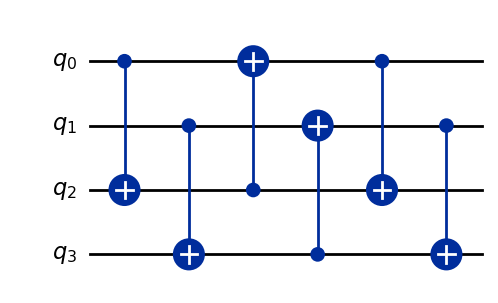

In [6]:
# Get the M4 operator
M4 = M4mod15()
 
# Add it to a circuit and plot
circ = QuantumCircuit(4)
circ.compose(M4, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

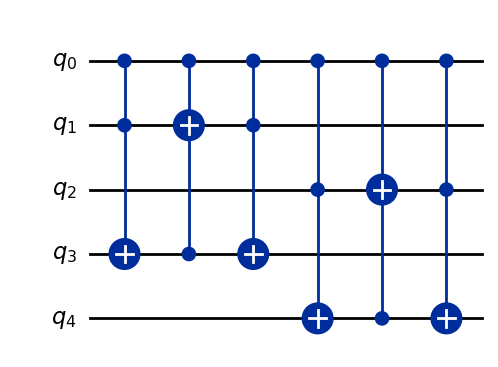

In [7]:
def controlled_M4mod15():
    """
    Controlled M4 (mod 15)
    """
    b = 4
    U = QuantumCircuit(4)
 
    U.swap(1, 3)
    U.swap(0, 2)
 
    U = U.to_gate()
    U.name = f"M_{b}"
    c_U = U.control()
 
    return c_U
# Get the controlled-M4 operator
controlled_M4 = controlled_M4mod15()
 
# Add it to a circuit and plot
circ = QuantumCircuit(5)
circ.compose(controlled_M4, inplace=True)
circ.decompose(reps=1).draw(output="mpl", fold=-1)

C:\Users\User\AppData\Local\Temp\ipykernel_8412\2249394097.py:39: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)


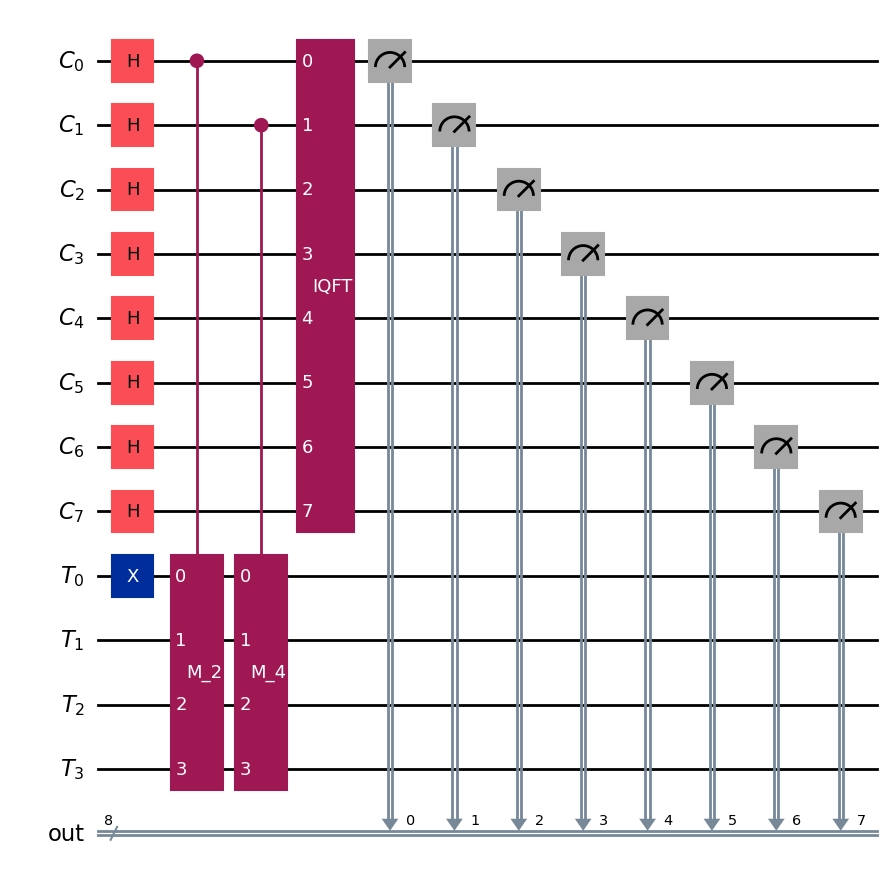

In [8]:
# Order finding problem for N = 15 with a = 2
N = 15
a = 2
 
# Number of qubits
num_target = floor(log(N - 1, 2)) + 1  # for modular exponentiation operators
num_control = 2 * num_target  # for enough precision of estimation
 
# List of M_b operators in order
k_list = range(num_control)
b_list = [a2kmodN(2, k, 15) for k in k_list]
 
# Initialize the circuit
control = QuantumRegister(num_control, name="C")
target = QuantumRegister(num_target, name="T")
output = ClassicalRegister(num_control, name="out")
circuit = QuantumCircuit(control, target, output)
 
# Initialize the target register to the state |1>
circuit.x(num_control)
 
# Add the Hadamard gates and controlled versions of the
# multiplication gates
for k, qubit in enumerate(control):
    circuit.h(k)
    b = b_list[k]
    if b == 2:
        circuit.compose(
            M2mod15().control(), qubits=[qubit] + list(target), inplace=True
        )
    elif b == 4:
        circuit.compose(
            M4mod15().control(), qubits=[qubit] + list(target), inplace=True
        )
    else:
        continue  # M1 is the identity operator
 
# Apply the inverse QFT to the control register
circuit.compose(QFT(num_control, inverse=True), qubits=control, inplace=True)
 
# Measure the control register
circuit.measure(control, output)
 
circuit.draw("mpl", fold=-1)

In [9]:
from qiskit_aer import AerSimulator
from qiskit import transpile

# Choose a simulator backend
backend = AerSimulator()

# Compile (transpile) the circuit for the backend
tcircuit = transpile(circuit, backend)

# Run the circuit
job = backend.run(tcircuit, shots=1024)

# Get the result
result = job.result()

# Extract measurement counts
counts = result.get_counts()

print(counts)


{'00000000': 275, '11000000': 237, '10000000': 257, '01000000': 255}


In [10]:
# Rows to be displayed in table
rows = []
# Corresponding phase of each bitstring
measured_phases = []
 
for output in counts:
    decimal = int(output, 2)  # Convert bitstring to decimal
    phase = decimal / (2**num_control)  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    rows.append(
        [
            f"{output}(bin) = {decimal:>3}(dec)",
            f"{decimal}/{2 ** num_control} = {phase:.2f}",
        ]
    )
 
# Print the rows in a table
headers = ["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
print(df)

            Register Output           Phase
0  00000000(bin) =   0(dec)    0/256 = 0.00
1  11000000(bin) = 192(dec)  192/256 = 0.75
2  10000000(bin) = 128(dec)  128/256 = 0.50
3  01000000(bin) =  64(dec)   64/256 = 0.25


In [11]:
# Rows to be displayed in a table
rows = []
 
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(15)
    rows.append(
        [phase, f"{frac.numerator}/{frac.denominator}", frac.denominator]
    )
 
# Print the rows in a table
headers = ["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows, columns=headers)
print(df)

   Phase Fraction  Guess for r
0   0.00      0/1            1
1   0.75      3/4            4
2   0.50      1/2            2
3   0.25      1/4            4
